# Clasificación automática de trámites (RUTS)

Este notebook explora si es posible clasificar trámites gubernamentales
en categorías utilizando únicamente texto libre.

Dataset: RUTS (colección `tramites`)
Etiqueta objetivo: `categoria`
Enfoque inicial: NLP clásico (TF-IDF + Logistic Regression)

Objetivo:
Evaluar si el contenido textual de los trámites contiene
información suficiente para predecir su categoría.


In [22]:
import json
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [23]:
import json
import pandas as pd

with open('ruts.tramites.json', "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)
df


,nombre,descripcion,requisitos,observaciones,categoria
0,Contratación de Agua Potable y Alcantarillado ...,Contratar el servicio de agua potable y alcant...,Requisitos para una Toma Doméstica:\n\n1.- Cos...,En el caso de presentar constancia notarial o ...,"[{'_id': {'$oid': '67c1d5fe9b31bf416b72a836'},..."
1,Sistema Empresarial de Financiamiento Hidalgo ...,Otorgar financiamiento a la micro y pequeña em...,Requisitos genéricos: \n\n1.-Acta de nacimient...,1.- El monto de los recursos se determinará en...,"[{'_id': {'$oid': '644ac23ee8c12207d215cd5f'},..."
2,Inconformidades en Materia de Obra Pública,Las personas físicas o morales interesados o a...,1.-Presentar la inconformidad por escrito.\n2....,No aplica,"[{'_id': {'$oid': '67f5806f7bf701698d80e437'},..."
3,Inconformidades en Materia de Adquisiciones,"Los licitantes o proveedores interesados, podr...",1.-Presentar la inconformidad por escrito.\n2....,Resolución de la Inconformidad.,"[{'_id': {'$oid': '67f5805b7bf70198b280e3ff'},..."
4,Asesoría y Capacitación en Materia de Contralo...,Proporcionar asesoría y capacitación en materi...,Ingresar con 7 días de anticipación a la fecha...,Ninguna,"[{'_id': {'$oid': '67f5801e7bf70177ea80e396'},..."
...,...,...,...,...,...
1995,Expedición y certificación de copia fiel del l...,Es una copia fiel fotostática del acto jurídi...,Datos de la persona solicitante,,"[{'_id': {'$oid': '5cc74762381d3b41e48265e0'},..."
1996,Expedición de constancia de inexistencia de foja,Es el resultado de la búsqueda minuciosa en nu...,Datos de la persona de quien se solicita la in...,,"[{'_id': {'$oid': '5cc74762381d3b41e48265ea'},..."
1997,Expedición de constancia de no matrimonio,Es el resultado de la búsqueda minuciosa en nu...,• Datos de la persona solicitante,,"[{'_id': {'$oid': '5cc74763381d3b41e48265f4'},..."
1998,Expedición de constancia de no registro de na...,Es el resultado de la búsqueda minuciosa en nu...,• Datos de la persona solicitante,,"[{'_id': {'$oid': '5cc74763381d3b41e48265fe'},..."


In [24]:
df["categoria"].head(3)


0    [{'_id': {'$oid': '67c1d5fe9b31bf416b72a836'},...
1    [{'_id': {'$oid': '644ac23ee8c12207d215cd5f'},...
2    [{'_id': {'$oid': '67f5806f7bf701698d80e437'},...
Name: categoria, dtype: object

In [25]:
def extraer_categoria(cat):
    if isinstance(cat, list) and len(cat) > 0:
        return cat[0]['categoria']
    return None

df["categoria_label"] = df["categoria"].apply(extraer_categoria)
df["categoria_label"]


0             Obras
1       Empresarial
2          Justicia
3          Justicia
4            Social
           ...     
1995      Población
1996      Población
1997         Social
1998      Población
1999         Social
Name: categoria_label, Length: 2000, dtype: object

In [26]:
df = df.dropna(subset=["categoria_label"])
df["categoria_label"].value_counts().head(10)


categoria_label
Población       473
Social          382
Educación       217
Obras           191
Empresarial     178
Finanzas        165
Salud            95
Agropecuario     80
Justicia         64
Cultura          57
Name: count, dtype: int64

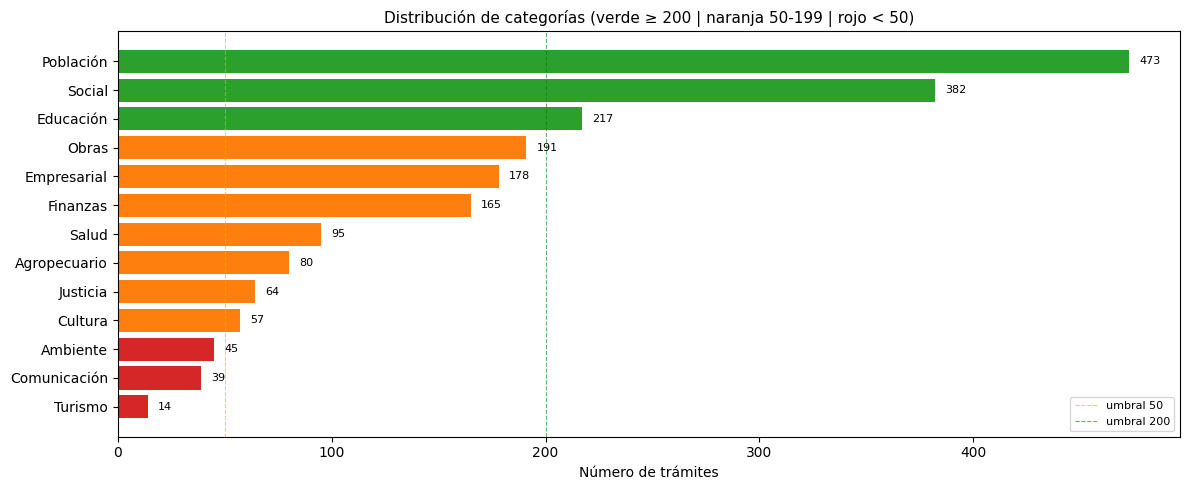

Total categorías: 13
Categorías con < 50 muestras: 3
Ratio max/min: 34x


In [27]:
import matplotlib.pyplot as plt

conteo_categorias = df["categoria_label"].value_counts()

fig, ax = plt.subplots(figsize=(12, max(5, len(conteo_categorias) * 0.35)))

colores = [
    "#d62728" if v < 50 else
    "#ff7f0e" if v < 200 else
    "#2ca02c"
    for v in conteo_categorias.values
]

barras = ax.barh(conteo_categorias.index[::-1], conteo_categorias.values[::-1], color=colores[::-1])

for barra, valor in zip(barras, conteo_categorias.values[::-1]):
    ax.text(
        barra.get_width() + conteo_categorias.values.max() * 0.01,
        barra.get_y() + barra.get_height() / 2,
        str(valor), va="center", fontsize=8
    )

ax.set_xlabel("Número de trámites")
ax.set_title("Distribución de categorías (verde ≥ 200 | naranja 50-199 | rojo < 50)", fontsize=11)
ax.axvline(x=50, color="orange", linestyle="--", linewidth=0.8, alpha=0.6, label="umbral 50")
ax.axvline(x=200, color="green", linestyle="--", linewidth=0.8, alpha=0.6, label="umbral 200")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Total categorías: {len(conteo_categorias)}")
print(f"Categorías con < 50 muestras: {(conteo_categorias < 50).sum()}")
print(f"Ratio max/min: {conteo_categorias.max() / conteo_categorias.min():.0f}x")

In [28]:
def construir_texto(row):
    campos = [
        str(row.get("nombre", "")),
        str(row.get("descripcion", "")),
        str(row.get("requisitos", "")),
        str(row.get("observaciones", ""))
    ]
    return " ".join(campos)

df["texto"] = df.apply(construir_texto, axis=1)
df['texto']

0       Contratación de Agua Potable y Alcantarillado ...
1       Sistema Empresarial de Financiamiento Hidalgo ...
2       Inconformidades en Materia de Obra Pública Las...
3       Inconformidades en Materia de Adquisiciones Lo...
4       Asesoría y Capacitación en Materia de Contralo...
                              ...                        
1995    Expedición y certificación de copia fiel del l...
1996    Expedición de constancia de  inexistencia de f...
1997    Expedición de constancia de  no matrimonio Es ...
1998    Expedición de constancia de  no registro de na...
1999    Permiso para la instalación o construcción de ...
Name: texto, Length: 2000, dtype: object

In [29]:
conteo = df["categoria_label"].value_counts()
categorias_validas = conteo[conteo >= 2].index

df = df[df["categoria_label"].isin(categorias_validas)]


In [30]:
X = df["texto"]
y = df["categoria_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [31]:
%pip install nltk


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [32]:
import nltk
nltk.download("stopwords")

from nltk.corpus import stopwords

stopwords_es = stopwords.words("spanish")


[nltk_data] Downloading package stopwords to /home/uplaph/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [33]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words=stopwords_es,
    ngram_range=(1,2)
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [34]:
model = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

model.fit(X_train_vec, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [35]:
y_pred = model.predict(X_test_vec)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

Agropecuario       0.82      0.56      0.67        16
    Ambiente       1.00      0.22      0.36         9
Comunicación       1.00      0.12      0.22         8
     Cultura       1.00      0.45      0.62        11
   Educación       0.89      0.91      0.90        43
 Empresarial       0.82      0.64      0.72        36
    Finanzas       1.00      0.64      0.78        33
    Justicia       1.00      0.15      0.27        13
       Obras       0.84      0.71      0.77        38
   Población       0.67      0.87      0.76        95
       Salud       0.92      0.58      0.71        19
      Social       0.51      0.80      0.63        76
     Turismo       0.00      0.00      0.00         3

    accuracy                           0.71       400
   macro avg       0.81      0.51      0.57       400
weighted avg       0.77      0.71      0.70       400



/home/uplaph/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/uplaph/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/uplaph/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

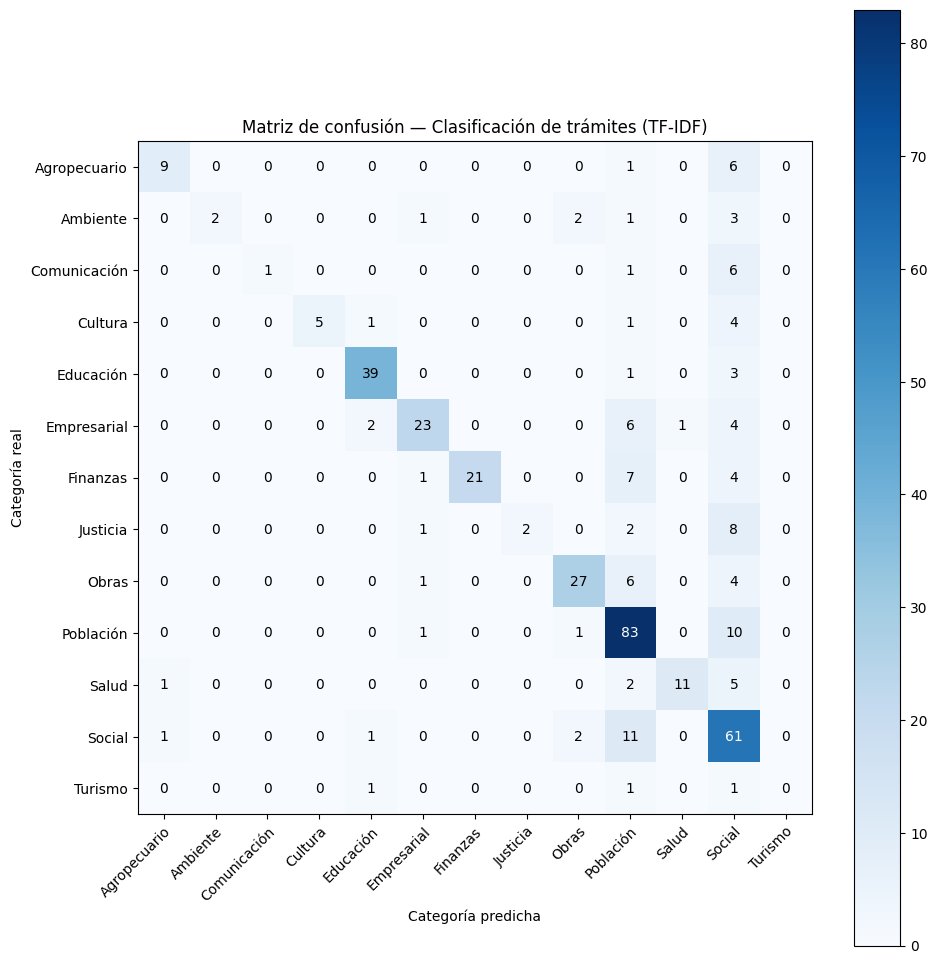

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Obtener etiquetas en el orden correcto
labels = sorted(y_test.unique())

# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=labels)

# Crear figura
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

# Barra de color
plt.colorbar(im, ax=ax)

# Etiquetas
ax.set(
    xticks=np.arange(len(labels)),
    yticks=np.arange(len(labels)),
    xticklabels=labels,
    yticklabels=labels,
    ylabel='Categoría real',
    xlabel='Categoría predicha',
    title='Matriz de confusión — Clasificación de trámites (TF-IDF)'
)

# Rotar etiquetas del eje X
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Mostrar valores dentro de cada celda
threshold = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, format(cm[i, j], 'd'),
            ha="center", va="center",
            color="white" if cm[i, j] > threshold else "black"
        )

plt.tight_layout()
plt.show()


La matriz de confusión muestra que los errores del modelo no son aleatorios, sino que se concentran entre categorías con alta proximidad semántica, lo cual sugiere que el modelo captura relaciones conceptuales presentes en el texto de los trámites.

In [37]:
conteo = df["categoria_label"].value_counts()
conteo


categoria_label
Población       473
Social          382
Educación       217
Obras           191
Empresarial     178
Finanzas        165
Salud            95
Agropecuario     80
Justicia         64
Cultura          57
Ambiente         45
Comunicación     39
Turismo          14
Name: count, dtype: int64

Predominan Población, Social (que lo considero lo mismo pero vadría la vpena identificar si tienen diferencias) y educación, tal vez Obras.<br>
Voy a usar:  
**Categorías con al menos 80 registros**  
📌 ¿Por qué 80?
- Es un umbral común en clasificación multiclase
- Permite estratificación
- Reduce clases “fantasma”

In [38]:
categorias_validas = conteo[conteo >= 80].index
df_camino_a = df[df["categoria_label"].isin(categorias_validas)]
df_camino_a

,nombre,descripcion,requisitos,observaciones,categoria,categoria_label,texto
0,Contratación de Agua Potable y Alcantarillado ...,Contratar el servicio de agua potable y alcant...,Requisitos para una Toma Doméstica:\n\n1.- Cos...,En el caso de presentar constancia notarial o ...,"[{'_id': {'$oid': '67c1d5fe9b31bf416b72a836'},...",Obras,Contratación de Agua Potable y Alcantarillado ...
1,Sistema Empresarial de Financiamiento Hidalgo ...,Otorgar financiamiento a la micro y pequeña em...,Requisitos genéricos: \n\n1.-Acta de nacimient...,1.- El monto de los recursos se determinará en...,"[{'_id': {'$oid': '644ac23ee8c12207d215cd5f'},...",Empresarial,Sistema Empresarial de Financiamiento Hidalgo ...
4,Asesoría y Capacitación en Materia de Contralo...,Proporcionar asesoría y capacitación en materi...,Ingresar con 7 días de anticipación a la fecha...,Ninguna,"[{'_id': {'$oid': '67f5801e7bf70177ea80e396'},...",Social,Asesoría y Capacitación en Materia de Contralo...
5,"Recepción y Seguimiento de Quejas, Denuncias y...",Atender las quejas y denuncias que presenta la...,1.- Ingresar en los buzones fijos que se encue...,No aplica,"[{'_id': {'$oid': '67f5810f7bf7019cd380e5d1'},...",Social,"Recepción y Seguimiento de Quejas, Denuncias y..."
6,Atención de Quejas y Denuncias,Cualquier persona podrá presentar una queja o ...,1.-Presentar la queja o denuncia.\n2.-Nombre d...,Ninguna,"[{'_id': {'$oid': '67f57ff87bf701db4f80e31f'},...",Social,Atención de Quejas y Denuncias Cualquier perso...
...,...,...,...,...,...,...,...
1995,Expedición y certificación de copia fiel del l...,Es una copia fiel fotostática del acto jurídi...,Datos de la persona solicitante,,"[{'_id': {'$oid': '5cc74762381d3b41e48265e0'},...",Población,Expedición y certificación de copia fiel del l...
1996,Expedición de constancia de inexistencia de foja,Es el resultado de la búsqueda minuciosa en nu...,Datos de la persona de quien se solicita la in...,,"[{'_id': {'$oid': '5cc74762381d3b41e48265ea'},...",Población,Expedición de constancia de inexistencia de f...
1997,Expedición de constancia de no matrimonio,Es el resultado de la búsqueda minuciosa en nu...,• Datos de la persona solicitante,,"[{'_id': {'$oid': '5cc74763381d3b41e48265f4'},...",Social,Expedición de constancia de no matrimonio Es ...
1998,Expedición de constancia de no registro de na...,Es el resultado de la búsqueda minuciosa en nu...,• Datos de la persona solicitante,,"[{'_id': {'$oid': '5cc74763381d3b41e48265fe'},...",Población,Expedición de constancia de no registro de na...


In [39]:
df_camino_a["categoria_label"].value_counts()


categoria_label
Población       473
Social          382
Educación       217
Obras           191
Empresarial     178
Finanzas        165
Salud            95
Agropecuario     80
Name: count, dtype: int64

In [40]:
X = df_camino_a["texto"]
y = df_camino_a["categoria_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [41]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words=stopwords_es,
    ngram_range=(1,2)
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [42]:
model = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

model.fit(X_train_vec, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [43]:
y_pred = model.predict(X_test_vec)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

Agropecuario       1.00      0.69      0.81        16
   Educación       0.94      0.79      0.86        43
 Empresarial       0.77      0.64      0.70        36
    Finanzas       0.96      0.76      0.85        33
       Obras       0.86      0.79      0.82        38
   Población       0.79      0.89      0.84        95
       Salud       1.00      0.37      0.54        19
      Social       0.60      0.81      0.69        77

    accuracy                           0.78       357
   macro avg       0.86      0.72      0.76       357
weighted avg       0.81      0.78      0.78       357



El bajo desempeño previo no era por falta de relación texto–categoría, sino por desbalance y ambigüedad estructural.

Los resultados muestran que el texto descriptivo de los trámites contiene información semántica suficiente para predecir su categoría administrativa con un alto nivel de precisión, siempre que exista una representación adecuada de datos por clase. La eliminación de categorías con baja frecuencia permitió mejorar significativamente las métricas macro-promediadas, evidenciando que el principal limitante del modelo no era el lenguaje natural, sino la estructura y distribución del dataset.

### **¿Los embeddings semánticos mejoran la clasificación respecto a TF-IDF en trámites gubernamentales?**

# 🧠 CAMINO C — Clasificación con embeddings semánticos
(Comparación justa vs TF-IDF)

In [44]:
!pip install sentence-transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 2.1 MB/s  0:00:05eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.4/637.4 kB 2.5 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 1.4 MB/s  0:00:02 eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 2.3 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.6/530.6 MB 10.0 MB/s  0:01:18m0:00:010:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 8.3 MB/s  0:00:38m0:00:0100:02m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 6.6 MB/s  0:00:26m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 12.6 MB/s  0:00:15m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 2.6 MB/s  0:00:23m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.2/188.2 MB 12.3 MB/s  0:00:15m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 649.8 kB/s  0:00:09 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━

In [45]:
from sentence_transformers import SentenceTransformer


/home/uplaph/.pyenv/versions/3.11.9/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [46]:
embedding_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10123.80it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [47]:
X_train_emb = embedding_model.encode(
    X_train.tolist(),
    show_progress_bar=True
)

X_test_emb = embedding_model.encode(
    X_test.tolist(),
    show_progress_bar=True
)


Batches: 100%|██████████| 12/12 [00:05<00:00,  2.13it/s]


In [48]:
model_emb = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

model_emb.fit(X_train_emb, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [49]:
y_pred_emb = model_emb.predict(X_test_emb)

print(classification_report(y_test, y_pred_emb))


              precision    recall  f1-score   support

Agropecuario       0.87      0.81      0.84        16
   Educación       0.86      0.86      0.86        43
 Empresarial       0.63      0.47      0.54        36
    Finanzas       0.69      0.82      0.75        33
       Obras       0.71      0.71      0.71        38
   Población       0.78      0.78      0.78        95
       Salud       0.63      0.63      0.63        19
      Social       0.67      0.70      0.68        77

    accuracy                           0.73       357
   macro avg       0.73      0.72      0.72       357
weighted avg       0.73      0.73      0.73       357



In [50]:
print("TF-IDF:")
print(classification_report(y_test, y_pred))
print("Embeddings:")
print(classification_report(y_test, y_pred_emb))

TF-IDF:
              precision    recall  f1-score   support

Agropecuario       1.00      0.69      0.81        16
   Educación       0.94      0.79      0.86        43
 Empresarial       0.77      0.64      0.70        36
    Finanzas       0.96      0.76      0.85        33
       Obras       0.86      0.79      0.82        38
   Población       0.79      0.89      0.84        95
       Salud       1.00      0.37      0.54        19
      Social       0.60      0.81      0.69        77

    accuracy                           0.78       357
   macro avg       0.86      0.72      0.76       357
weighted avg       0.81      0.78      0.78       357

Embeddings:
              precision    recall  f1-score   support

Agropecuario       0.87      0.81      0.84        16
   Educación       0.86      0.86      0.86        43
 Empresarial       0.63      0.47      0.54        36
    Finanzas       0.69      0.82      0.75        33
       Obras       0.71      0.71      0.71        38
   P

# Task
Compare the performance of TF-IDF and Embeddings models for document classification by:
1. Extracting the classification reports for both models as dictionaries.
2. Converting these dictionaries into pandas DataFrames, ensuring that categories are aligned.
3. Generating line plots to visualize and compare the precision, recall, and f1-score of each model across all categories.

## Extract classification reports as dictionaries

### Subtask:
Parse the classification reports for TF-IDF and Embeddings into dictionaries to easily access precision, recall, and f1-score for each category.


**Reasoning**:
I will generate the classification reports for both the TF-IDF and Embeddings models as dictionaries, as specified in the instructions, to prepare them for further analysis.



In [51]:
from sklearn.metrics import classification_report

report_tfidf_dict = classification_report(y_test, y_pred, output_dict=True)
report_emb_dict = classification_report(y_test, y_pred_emb, output_dict=True)

print("TF-IDF Report Dictionary Keys:", report_tfidf_dict.keys())
print("Embeddings Report Dictionary Keys:", report_emb_dict.keys())

TF-IDF Report Dictionary Keys: dict_keys(['Agropecuario', 'Educación', 'Empresarial', 'Finanzas', 'Obras', 'Población', 'Salud', 'Social', 'accuracy', 'macro avg', 'weighted avg'])
Embeddings Report Dictionary Keys: dict_keys(['Agropecuario', 'Educación', 'Empresarial', 'Finanzas', 'Obras', 'Población', 'Salud', 'Social', 'accuracy', 'macro avg', 'weighted avg'])


**Reasoning**:
Now that the classification reports are in dictionary format, I will convert them into pandas DataFrames to facilitate comparison and further analysis, as specified by the task instructions. This step also involves aligning the categories correctly.



In [52]:
df_report_tfidf = pd.DataFrame(report_tfidf_dict).transpose()
df_report_emb = pd.DataFrame(report_emb_dict).transpose()

# Filter out 'accuracy', 'macro avg', 'weighted avg' rows as they are not categories
df_report_tfidf = df_report_tfidf.loc[~df_report_tfidf.index.isin(['accuracy', 'macro avg', 'weighted avg'])]
df_report_emb = df_report_emb.loc[~df_report_emb.index.isin(['accuracy', 'macro avg', 'weighted avg'])]

print("TF-IDF Report DataFrame Head:")
print(df_report_tfidf.head())
print("\nEmbeddings Report DataFrame Head:")
print(df_report_emb.head())

TF-IDF Report DataFrame Head:
              precision    recall  f1-score  support
Agropecuario   1.000000  0.687500  0.814815     16.0
Educación      0.944444  0.790698  0.860759     43.0
Empresarial    0.766667  0.638889  0.696970     36.0
Finanzas       0.961538  0.757576  0.847458     33.0
Obras          0.857143  0.789474  0.821918     38.0

Embeddings Report DataFrame Head:
              precision    recall  f1-score  support
Agropecuario   0.866667  0.812500  0.838710     16.0
Educación      0.860465  0.860465  0.860465     43.0
Empresarial    0.629630  0.472222  0.539683     36.0
Finanzas       0.692308  0.818182  0.750000     33.0
Obras          0.710526  0.710526  0.710526     38.0


**Reasoning**:
I will generate line plots using `matplotlib.pyplot` to visualize and compare the precision, recall, and f1-score for both TF-IDF and Embeddings models across all categories. This directly addresses the third instruction of the main task.



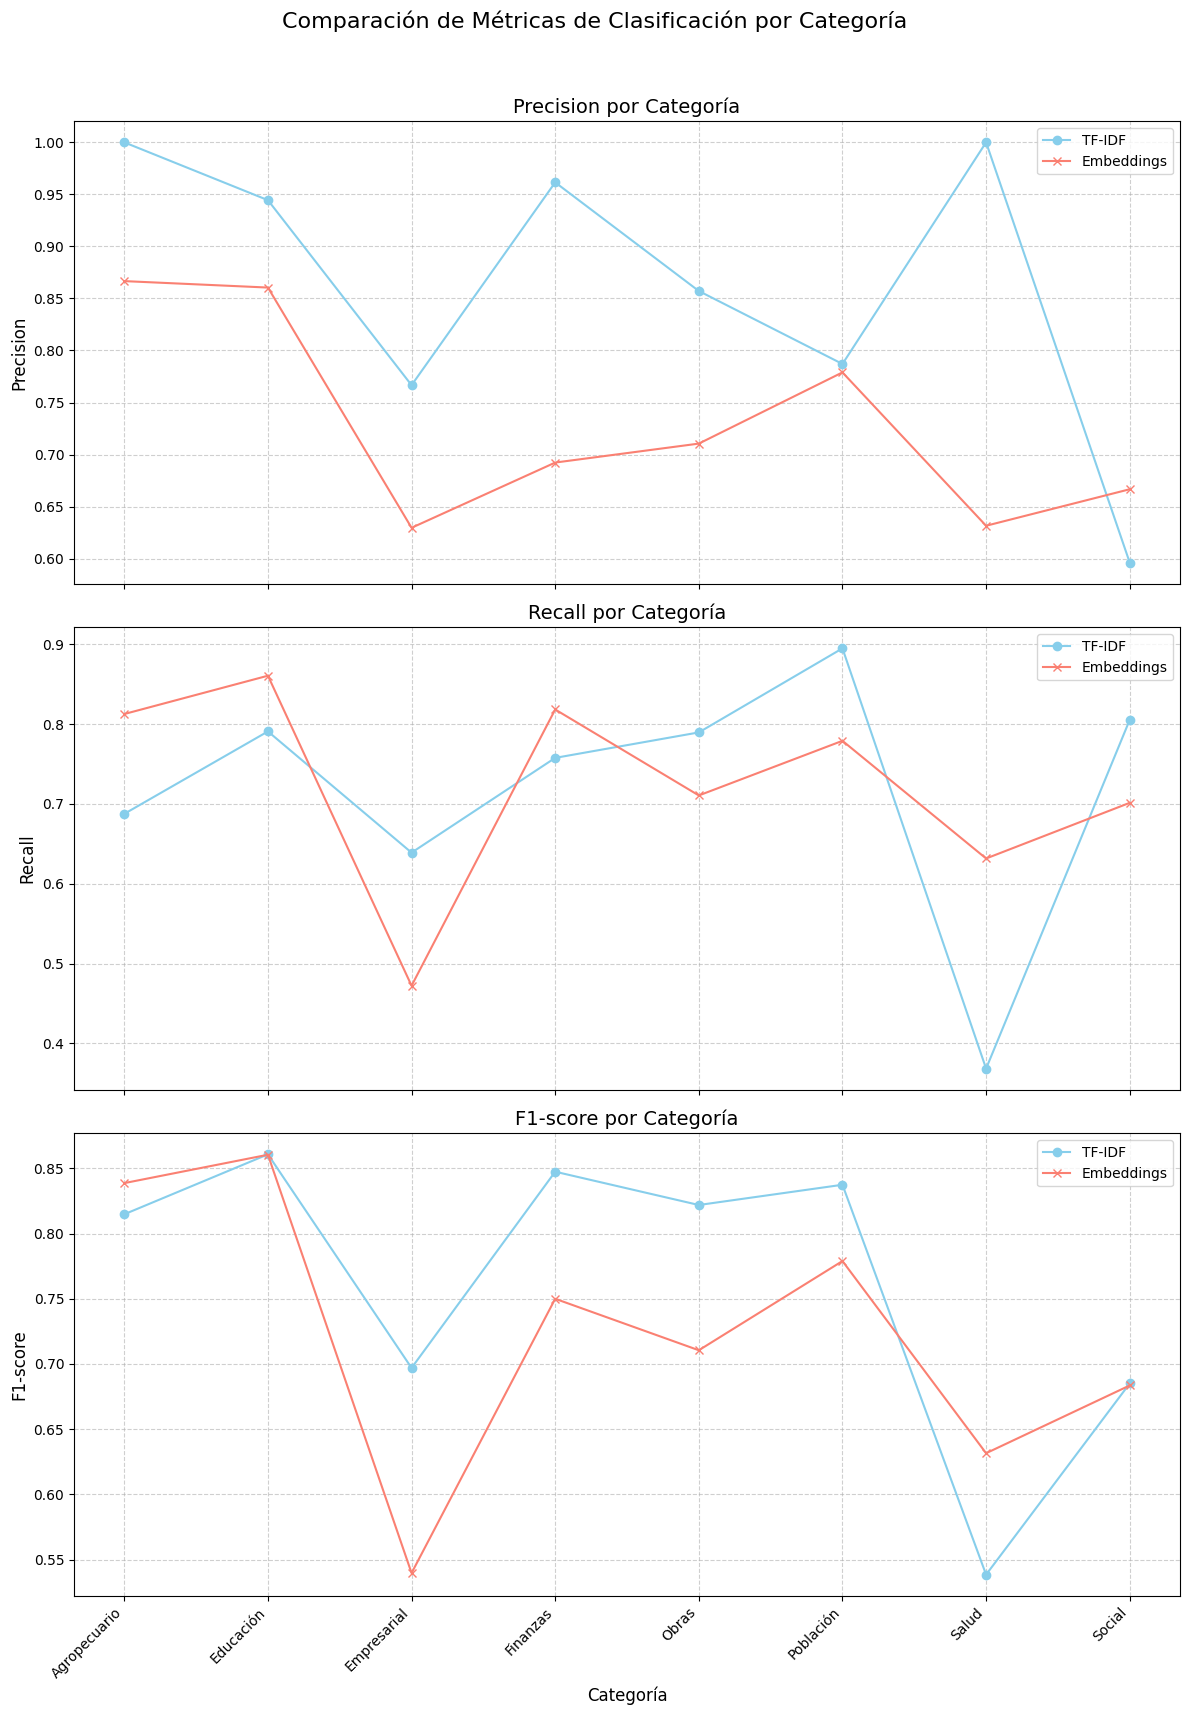

In [53]:
import matplotlib.pyplot as plt

metrics = ['precision', 'recall', 'f1-score']
categories = df_report_tfidf.index # Categories are the same for both dataframes

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 18), sharex=True)
fig.suptitle('Comparación de Métricas de Clasificación por Categoría', fontsize=16)

for i, metric in enumerate(metrics):
    axes[i].plot(categories, df_report_tfidf[metric], marker='o', label='TF-IDF', color='skyblue')
    axes[i].plot(categories, df_report_emb[metric], marker='x', label='Embeddings', color='salmon')
    axes[i].set_ylabel(metric.capitalize(), fontsize=12)
    axes[i].set_title(f'{metric.capitalize()} por Categoría', fontsize=14)
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.6)

axes[-1].set_xlabel('Categoría', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

Los resultados muestran que el modelo basado en TF-IDF presenta un mejor desempeño global que el enfoque basado en embeddings semánticos, tanto en precisión como en recall y métricas F1. Si bien los embeddings muestran una ligera mejora en la recuperación de ciertas categorías ambiguas como Salud, esta mejora se produce a costa de una disminución en precisión y estabilidad en otras categorías. Esto sugiere que, para trámites gubernamentales con lenguaje altamente estructurado e institucionalizado, los enfoques basados en frecuencia siguen siendo más adecuados.

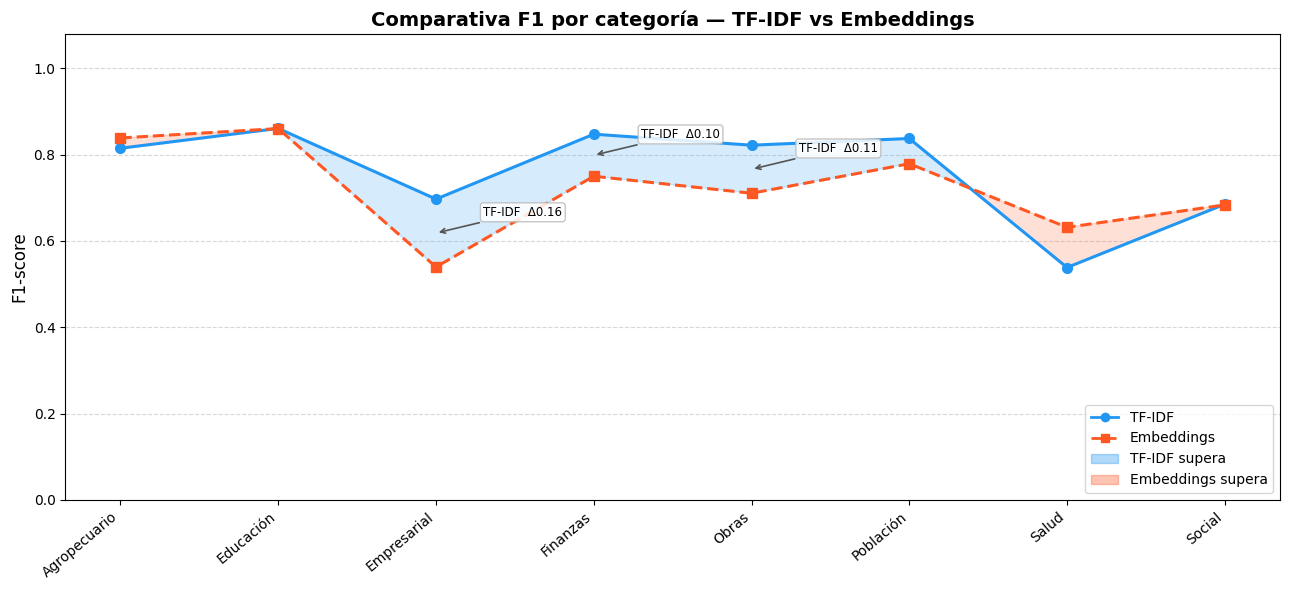

In [54]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- Datos: F1 por categoría ---
categorias = df_report_tfidf.index.tolist()
f1_tfidf = df_report_tfidf['f1-score'].astype(float).values
f1_emb   = df_report_emb['f1-score'].astype(float).values
diff     = f1_tfidf - f1_emb   # positivo → TF-IDF gana

x = np.arange(len(categorias))

fig, ax = plt.subplots(figsize=(13, 6))

# --- Área de divergencia ---
# Verde donde TF-IDF > Embeddings, naranja donde Embeddings > TF-IDF
ax.fill_between(x, f1_tfidf, f1_emb,
                where=(f1_tfidf >= f1_emb),
                interpolate=True, alpha=0.18,
                color='#2196F3', label='_nolegend_')
ax.fill_between(x, f1_tfidf, f1_emb,
                where=(f1_emb > f1_tfidf),
                interpolate=True, alpha=0.18,
                color='#FF5722', label='_nolegend_')

# --- Curvas ---
ax.plot(x, f1_tfidf, marker='o', linewidth=2.2, markersize=7,
        color='#2196F3', label='TF-IDF')
ax.plot(x, f1_emb,   marker='s', linewidth=2.2, markersize=7,
        color='#FF5722', label='Embeddings', linestyle='--')

# --- Anotaciones: top-3 mayores divergencias ---
top_idx = np.argsort(np.abs(diff))[-3:]
for idx in top_idx:
    gap = diff[idx]
    winner = 'TF-IDF' if gap > 0 else 'Emb'
    y_mid = (f1_tfidf[idx] + f1_emb[idx]) / 2
    ax.annotate(
        f'{winner}  Δ{abs(gap):.2f}',
        xy=(x[idx], y_mid),
        xytext=(x[idx] + 0.3, y_mid + 0.04),
        fontsize=8.5,
        arrowprops=dict(arrowstyle='->', color='#555', lw=1.2),
        bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#bbb', alpha=0.85)
    )

# --- Estilo ---
ax.set_xticks(x)
ax.set_xticklabels(categorias, rotation=40, ha='right', fontsize=10)
ax.set_ylabel('F1-score', fontsize=12)
ax.set_title('Comparativa F1 por categoría — TF-IDF vs Embeddings', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.08)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Leyenda manual (incluye parches de área)
patch_tfidf = mpatches.Patch(color='#2196F3', alpha=0.35, label='TF-IDF supera')
patch_emb   = mpatches.Patch(color='#FF5722', alpha=0.35, label='Embeddings supera')
line_tfidf  = plt.Line2D([0],[0], color='#2196F3', marker='o', linewidth=2, label='TF-IDF')
line_emb    = plt.Line2D([0],[0], color='#FF5722', marker='s', linewidth=2, linestyle='--', label='Embeddings')
ax.legend(handles=[line_tfidf, line_emb, patch_tfidf, patch_emb],
          loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()


La zona azul indica categorías donde TF-IDF supera a Embeddings; la zona naranja, lo contrario. Las anotaciones señalan las tres mayores divergencias, facilitando identificar dónde el enfoque léxico y el semántico difieren más.